# [ML] ALS + Twiddler 다양성 지표 — 2026-07-08

**목적**: ALS 오프라인 추천에 Twiddler 재랭킹(페르소나 카테고리 가중치 + 노출 이력 패널티)을 반복 새로고침 상황으로 시뮬레이션해 적용했을 때, 정확도(HR/Recall/NDCG)와 다양성(세션 간 중복률, 카테고리 커버리지)이 어떻게 달라지는지 확인한다.

| 항목 | 내용 |
|---|---|
| 데이터셋 | `data/outputs/ALS/PRED_MAIN_RECOMMEND.csv` (dataset=full, 유저별 top-100 ALS 추천) |
| 정답셋 | `data/outputs/ALS/als_test.csv` (split_date=2025-08-01 이후 **purchase** 이벤트만) |
| 페르소나 | `data/processed/customer_segments_labeled_train_only.csv` (train 기간 기준 세그먼트) |
| 평가 지표 | 정확도: HR@K·Recall@K·NDCG@K (K=5,10,20) / 다양성: 세션 간 아이템 중복률, 고유 아이템 비율, 카테고리 커버리지 |
| 재현성 | `random_state=42` 고정 |

**핵심 가정 및 방법론적 제약**
- Rule 3(저노출 상품 최소 노출 보장)은 `backend/api/services/twiddler_service.py` 기준 main(ALS) 컨텍스트에는 애초에 적용되지 않는 규칙이라 이 분석에서도 제외한다.
- "반복 새로고침"은 한 유저가 T=5회 연속 새로고침한다는 시뮬레이션 가정이며, 실제 세션 간격이나 중도 이탈은 반영하지 않는다.
- 페르소나 라벨은 train 기간 데이터로만 산출되어 test 기간의 행동 변화(선호 이동 등)는 반영되지 않는다.
- exposure_counts는 유저별로 시뮬레이션 시작 시점에 빈 상태(첫 방문)에서 출발한다 — 실제 서비스에서 이전 방문의 노출 이력이 남아있는 경우와는 다를 수 있다.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

REPO_ROOT = Path(".").resolve().parent  # notebooks/ 기준 리포 루트
sys.path.insert(0, str(REPO_ROOT))

from src.modeling.twiddler import rerank as rerank_mod
from src.modeling.als.evaluate import hit_rate_at_k, recall_at_k, ndcg_at_k
from backend.api.services import persona_service, catalog_service

sns.set_style("whitegrid")
PALETTE = sns.color_palette("colorblind")
plt.rcParams.update({
    "font.family": "Malgun Gothic",  # Windows 한국어 폰트. Mac은 'AppleGothic', Linux는 'NanumGothic'
    "axes.unicode_minus": False,
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 11,
})

np.random.seed(42)

OUTPUT_DIR = REPO_ROOT / "data" / "outputs" / "ALS"
K_LIST = [5, 10, 20]
T_SESSIONS = 5  # 반복 새로고침 횟수
POOL_MULTIPLIER = rerank_mod.POOL_MULTIPLIER
EXPOSURE_DECAY = rerank_mod.EXPOSURE_DECAY

## 1. 데이터 로드 & 검증

In [2]:
recs_df = pd.read_csv(OUTPUT_DIR / "PRED_MAIN_RECOMMEND.csv")
test_df = pd.read_csv(OUTPUT_DIR / "als_test.csv")

print("[검증] PRED_MAIN_RECOMMEND.csv")
print(f"  shape={recs_df.shape}, dtypes={dict(recs_df.dtypes.astype(str))}")
print(f"  null 비율(%):\n{(recs_df.isna().mean() * 100).round(2)}")
print(f"  중복 행 수: {recs_df.duplicated().sum()}")

print("\n[검증] als_test.csv")
print(f"  shape={test_df.shape}, 중복 행 수: {test_df.duplicated().sum()}")

ground_truth = test_df.groupby("user_id")["item_id"].apply(set).to_dict()
eval_users = list(ground_truth.keys())
category_map = catalog_service.get_category_map()
user_type_map = recs_df.drop_duplicates("user_id").set_index("user_id")["user_type"].to_dict()

recs_by_user = {
    uid: g.sort_values("rank")[["item_id", "score"]].to_dict("records")
    for uid, g in recs_df[recs_df["user_id"].isin(eval_users)].groupby("user_id")
}
print(f"\n평가 대상 유저 수: {len(eval_users):,}명 "
      f"(heavy={sum(1 for u in eval_users if user_type_map.get(u)=='heavy')}, "
      f"cold={sum(1 for u in eval_users if user_type_map.get(u)=='cold')})")

[검증] PRED_MAIN_RECOMMEND.csv
  shape=(1993000, 5), dtypes={'user_id': 'int64', 'item_id': 'int64', 'score': 'float64', 'rank': 'int64', 'user_type': 'str'}
  null 비율(%):
user_id      0.0
item_id      0.0
score        0.0
rank         0.0
user_type    0.0
dtype: float64
  중복 행 수: 0

[검증] als_test.csv
  shape=(2742, 2), 중복 행 수: 0

평가 대상 유저 수: 1,463명 (heavy=1427, cold=36)

## 2. 베이스라인: 단일 세션(1회 추천) 정확도

새로고침을 시뮬레이션하기 전, ALS 원점수만 사용한 경우와 Twiddler Rule 1(페르소나 카테고리 가중치)만 적용한 경우의 1회성 정확도를 먼저 확인한다. Rule 2(노출 이력)는 반복 노출이 있어야 의미가 생기므로 여기서는 제외한다.

In [3]:
def single_session_metrics(k: int, condition: str) -> dict:
    """1회성 추천 기준 HR/Recall/NDCG@k 계산."""
    pool_n = k * POOL_MULTIPLIER
    hr_list, recall_list, ndcg_list = [], [], []
    for uid in eval_users:
        if uid not in recs_by_user:
            continue
        candidates = [dict(it) for it in recs_by_user[uid][:pool_n]]
        persona_label = persona_service.get_persona(uid)

        if condition == "als_only" or persona_label is None:
            recommended = [it["item_id"] for it in candidates[:k]]
        else:
            affinity = persona_service.get_segment_affinity(persona_label)
            alpha = persona_service.get_segment_alpha(persona_label)
            reranked = rerank_mod.rerank(
                candidates, id_key="item_id", category_map=category_map,
                affinity=affinity, alpha=alpha,
                exposure_counts=None, low_exposure_ids=None, top_k=k,
            )
            recommended = [it["item_id"] for it in reranked]

        true_items = ground_truth[uid]
        hr_list.append(hit_rate_at_k(recommended, true_items))
        recall_list.append(recall_at_k(recommended, true_items))
        ndcg_list.append(ndcg_at_k(recommended, true_items))

    return {"k": k, "condition": condition,
            "HR": round(np.mean(hr_list), 4), "Recall": round(np.mean(recall_list), 4),
            "NDCG": round(np.mean(ndcg_list), 4), "eval_users": len(hr_list)}


baseline_rows = [single_session_metrics(k, c) for k in K_LIST for c in ["als_only", "rule1_only"]]
baseline_df = pd.DataFrame(baseline_rows)
print(baseline_df.to_string(index=False))

 k  condition     HR  Recall   NDCG  eval_users
 5   als_only 0.0171  0.0098 0.0075        1463
 5 rule1_only 0.0191  0.0111 0.0076        1463
10   als_only 0.0369  0.0202 0.0114        1463
10 rule1_only 0.0349  0.0183 0.0105        1463
20   als_only 0.0608  0.0330 0.0152        1463
20 rule1_only 0.0615  0.0338 0.0149        1463

## 3. 반복 새로고침(세션) 시뮬레이션 — Rule 2 포함

유저 1명이 같은 화면을 T=5회 연속 새로고침한다고 가정하고, 매 세션마다 추천을 다시 계산한다. 3가지 조건을 비교한다.

- **als_only**: ALS 원점수 그대로 top-K (Twiddler 미적용) — 매 세션 후보 풀과 순위가 동일하므로 항상 같은 결과
- **rule1_only**: Rule 1(페르소나 카테고리 가중치)만 적용, 노출 이력 없음 — 이 배율도 세션마다 바뀌지 않으므로 역시 항상 같은 결과
- **rule1_rule2**: Rule 1 + Rule 2(노출 이력 패널티) — 이전 세션에서 보여준 아이템은 다음 세션에서 점수가 깎여 밀려난다

`exposure_counts` 갱신 로직은 `backend/api/services/exposure_service.record_exposure`를 그대로 재현한다: 매 세션마다 기존 노출 카운트를 `EXPOSURE_DECAY`(=0.7)만큼 감쇠시킨 뒤, 이번에 보여준 아이템에 +1 한다.

In [4]:
def decay_and_record(exposure_counts: dict, shown_item_ids: list) -> None:
    """backend/api/services/exposure_service.record_exposure와 동일한 갱신 로직."""
    for item_id in list(exposure_counts.keys()):
        decayed = exposure_counts[item_id] * EXPOSURE_DECAY
        if decayed < 0.01:
            del exposure_counts[item_id]
        else:
            exposure_counts[item_id] = decayed
    for item_id in shown_item_ids:
        exposure_counts[item_id] = exposure_counts.get(item_id, 0.0) + 1.0


def simulate_user_sessions(candidates_base, persona_label, affinity, alpha, k, condition):
    """유저 1명에 대해 T_SESSIONS회 새로고침을 시뮬레이션해 세션별 추천 아이템 리스트를 반환."""
    exposure_counts: dict = {}
    sessions = []
    for _ in range(T_SESSIONS):
        candidates = [dict(it) for it in candidates_base]  # 매 세션 ALS 원점수부터 재계산
        if condition == "als_only" or persona_label is None:
            slate = [it["item_id"] for it in candidates[:k]]
        else:
            exposure_arg = exposure_counts if (condition == "rule1_rule2" and exposure_counts) else None
            reranked = rerank_mod.rerank(
                candidates, id_key="item_id", category_map=category_map,
                affinity=affinity, alpha=alpha,
                exposure_counts=exposure_arg, low_exposure_ids=None, top_k=k,
            )
            slate = [it["item_id"] for it in reranked]
        sessions.append(slate)
        if condition == "rule1_rule2":
            decay_and_record(exposure_counts, slate)
    return sessions


def diversity_metrics(sessions: list, k: int) -> dict:
    """T개 세션 슬레이트로부터 유저 1명의 다양성 지표 계산."""
    first = set(sessions[0])
    overlaps = [len(first & set(s)) / k for s in sessions[1:]]
    all_items = [it for s in sessions for it in s]
    all_categories = {category_map.get(it) for it in all_items} - {None}
    first_categories = {category_map.get(it) for it in sessions[0]} - {None}
    return {
        "repetition_rate": np.mean(overlaps) if overlaps else 1.0,
        "unique_item_ratio": len(set(all_items)) / (k * len(sessions)),
        "categories_1session": len(first_categories),
        "categories_5sessions": len(all_categories),
    }

In [5]:
diversity_rows = []
for k in K_LIST:
    pool_n = k * POOL_MULTIPLIER
    for condition in ["als_only", "rule1_only", "rule1_rule2"]:
        acc = {"repetition_rate": [], "unique_item_ratio": [], "categories_1session": [], "categories_5sessions": []}
        for uid in eval_users:
            if uid not in recs_by_user:
                continue
            candidates_base = recs_by_user[uid][:pool_n]
            persona_label = persona_service.get_persona(uid)
            affinity = persona_service.get_segment_affinity(persona_label) if persona_label else {}
            alpha = persona_service.get_segment_alpha(persona_label) if persona_label else 0.0
            sessions = simulate_user_sessions(candidates_base, persona_label, affinity, alpha, k, condition)
            m = diversity_metrics(sessions, k)
            for key in acc:
                acc[key].append(m[key])
        diversity_rows.append({
            "k": k, "condition": condition,
            "repetition_rate": round(np.mean(acc["repetition_rate"]), 4),
            "unique_item_ratio": round(np.mean(acc["unique_item_ratio"]), 4),
            "categories_1session": round(np.mean(acc["categories_1session"]), 2),
            "categories_5sessions": round(np.mean(acc["categories_5sessions"]), 2),
            "n_users": len(acc["repetition_rate"]),
        })

diversity_df = pd.DataFrame(diversity_rows)
print(diversity_df.to_string(index=False))

 k   condition  repetition_rate  unique_item_ratio  categories_1session  categories_5sessions  n_users
 5    als_only           1.0000             0.2000                 2.21                  2.21     1463
 5  rule1_only           1.0000             0.2000                 2.13                  2.13     1463
 5 rule1_rule2           0.3539             0.5879                 2.13                  3.69     1463
10    als_only           1.0000             0.2000                 3.13                  3.13     1463
10  rule1_only           1.0000             0.2000                 2.93                  2.93     1463
10 rule1_rule2           0.3942             0.5702                 2.93                  4.74     1463
20    als_only           1.0000             0.2000                 4.28                  4.28     1463
20  rule1_only           1.0000             0.2000                 3.97                  3.97     1463
20 rule1_rule2           0.4493             0.5319                 3.97  

## 4. user_type(heavy/cold)별 결과 (K=10)

cold 유저는 ALS 개인화가 아닌 인기도 폴백 리스트를 받는다 — 이 폴백 리스트에도 Twiddler가 동일하게 적용되는지 확인한다.

In [6]:
k = 10
pool_n = k * POOL_MULTIPLIER
type_rows = []
for condition in ["als_only", "rule1_rule2"]:
    for utype in ["heavy", "cold"]:
        acc = {"repetition_rate": [], "unique_item_ratio": []}
        for uid in eval_users:
            if uid not in recs_by_user or user_type_map.get(uid) != utype:
                continue
            candidates_base = recs_by_user[uid][:pool_n]
            persona_label = persona_service.get_persona(uid)
            affinity = persona_service.get_segment_affinity(persona_label) if persona_label else {}
            alpha = persona_service.get_segment_alpha(persona_label) if persona_label else 0.0
            sessions = simulate_user_sessions(candidates_base, persona_label, affinity, alpha, k, condition)
            m = diversity_metrics(sessions, k)
            acc["repetition_rate"].append(m["repetition_rate"])
            acc["unique_item_ratio"].append(m["unique_item_ratio"])
        if acc["repetition_rate"]:
            type_rows.append({
                "condition": condition, "user_type": utype,
                "repetition_rate": round(np.mean(acc["repetition_rate"]), 4),
                "unique_item_ratio": round(np.mean(acc["unique_item_ratio"]), 4),
                "n_users": len(acc["repetition_rate"]),
            })
type_df = pd.DataFrame(type_rows)
print(type_df.to_string(index=False))

  condition user_type  repetition_rate  unique_item_ratio  n_users
   als_only     heavy           1.0000             0.2000     1427
   als_only      cold           1.0000             0.2000       36
rule1_rule2     heavy           0.3948             0.5694     1427
rule1_rule2      cold           0.3681             0.6000       36

## 5. 세션 누적 성장 곡선 (K=10)

새로고침을 거듭할수록 누적 고유 아이템/카테고리 수가 어떻게 늘어나는지 세션별로 추적한다.

In [7]:
k = 10
pool_n = k * POOL_MULTIPLIER
curve_acc = {c: {"categories": [[] for _ in range(T_SESSIONS)], "items": [[] for _ in range(T_SESSIONS)]}
             for c in ["als_only", "rule1_rule2"]}

for condition in curve_acc:
    for uid in eval_users:
        if uid not in recs_by_user:
            continue
        candidates_base = recs_by_user[uid][:pool_n]
        persona_label = persona_service.get_persona(uid)
        affinity = persona_service.get_segment_affinity(persona_label) if persona_label else {}
        alpha = persona_service.get_segment_alpha(persona_label) if persona_label else 0.0
        sessions = simulate_user_sessions(candidates_base, persona_label, affinity, alpha, k, condition)

        seen_items, seen_categories = set(), set()
        for t, slate in enumerate(sessions):
            seen_items |= set(slate)
            seen_categories |= ({category_map.get(it) for it in slate} - {None})
            curve_acc[condition]["items"][t].append(len(seen_items))
            curve_acc[condition]["categories"][t].append(len(seen_categories))

curve_df = pd.DataFrame({
    "session": range(1, T_SESSIONS + 1),
    "als_only_categories": [np.mean(curve_acc["als_only"]["categories"][t]) for t in range(T_SESSIONS)],
    "rule1_rule2_categories": [np.mean(curve_acc["rule1_rule2"]["categories"][t]) for t in range(T_SESSIONS)],
    "als_only_items": [np.mean(curve_acc["als_only"]["items"][t]) for t in range(T_SESSIONS)],
    "rule1_rule2_items": [np.mean(curve_acc["rule1_rule2"]["items"][t]) for t in range(T_SESSIONS)],
})
print(curve_df.round(3).to_string(index=False))

 session  als_only_categories  rule1_rule2_categories  als_only_items  rule1_rule2_items
       1                 3.125                   2.932            10.0             10.000
       2                 3.125                   3.826            10.0             17.982
       3                 3.125                   4.221            10.0             22.991
       4                 3.125                   4.614            10.0             27.338
       5                 3.125                   4.738            10.0             28.510

## 6. 시각화

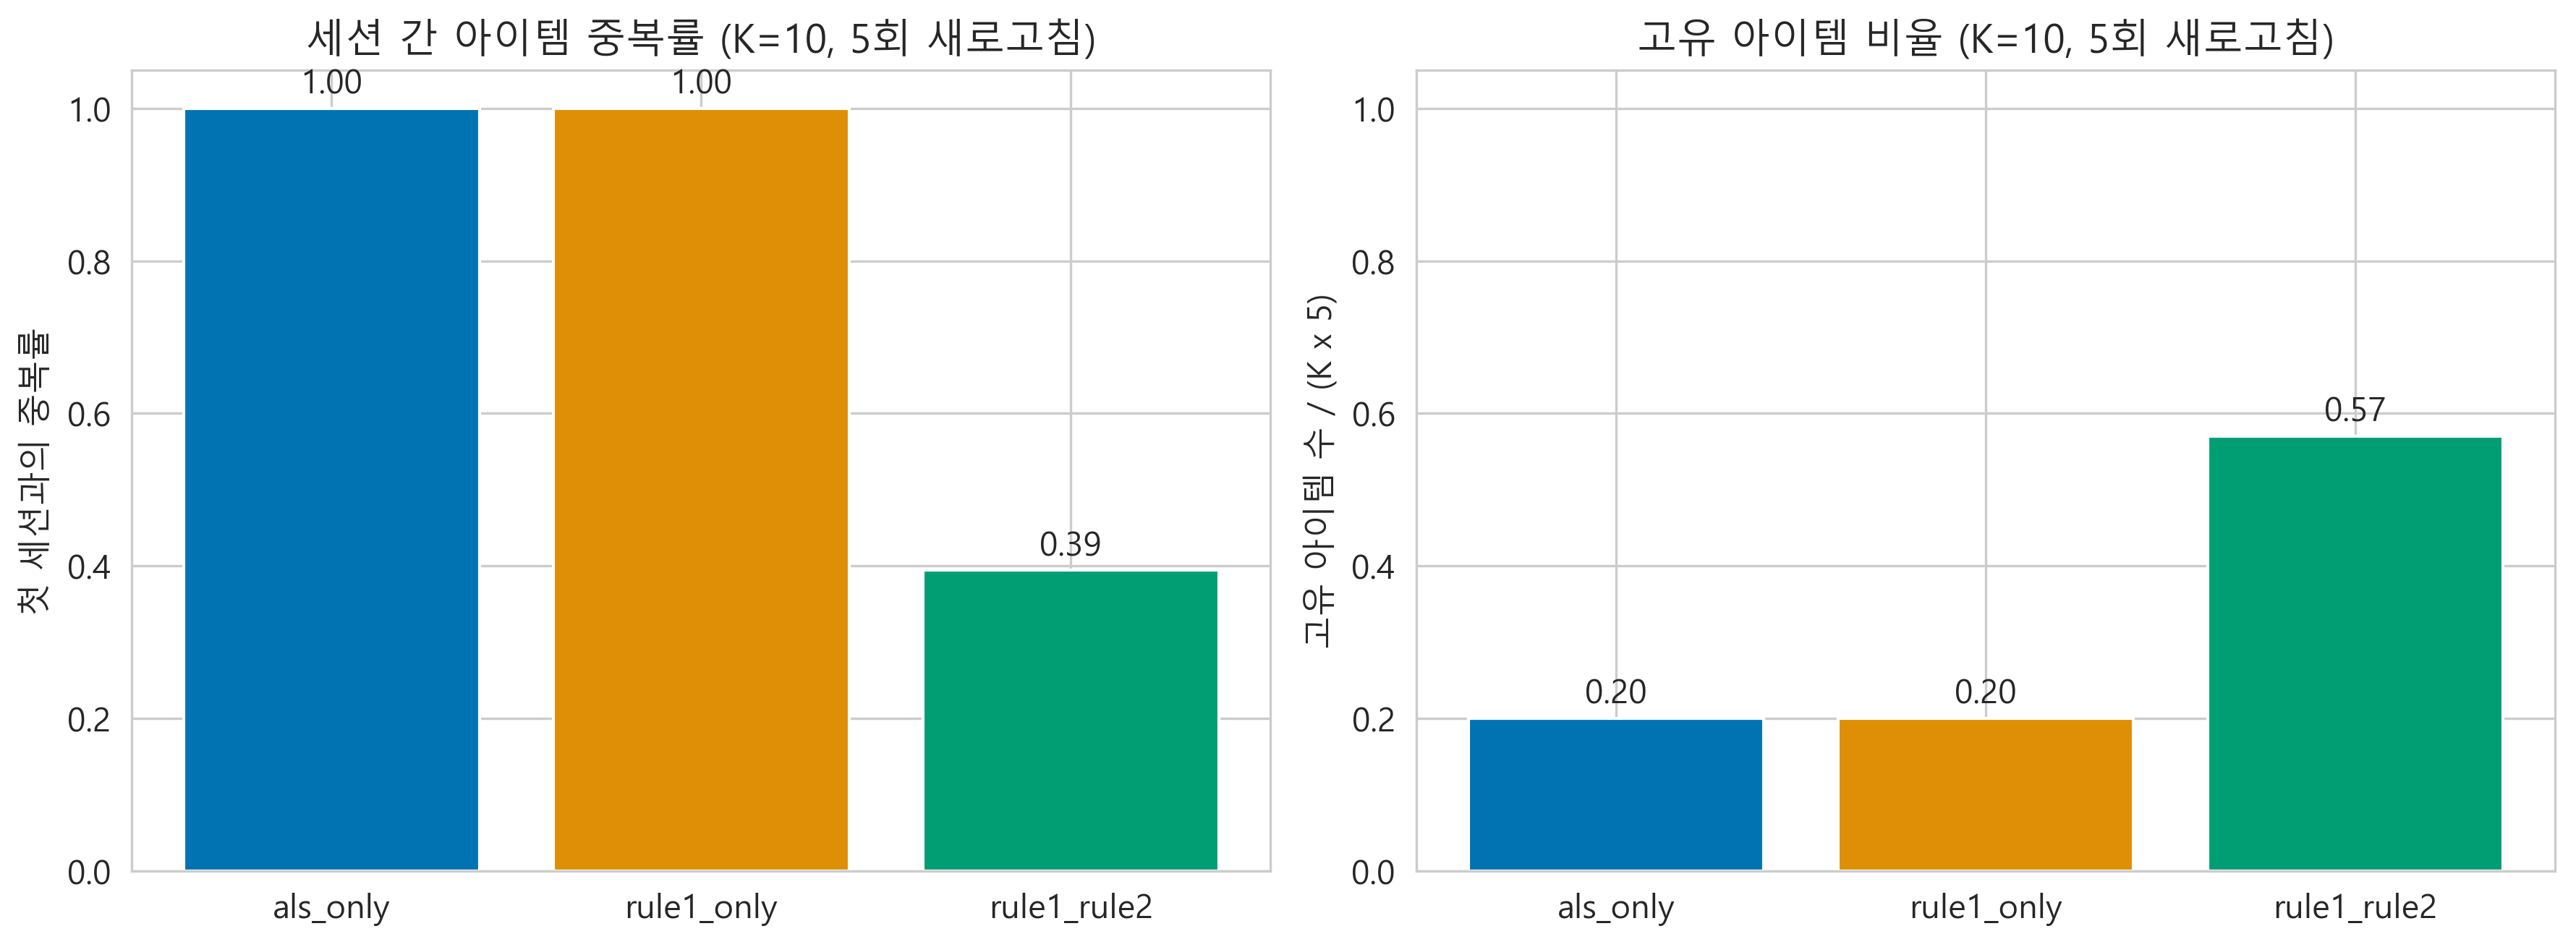

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sub = diversity_df[diversity_df["k"] == 10]
axes[0].bar(sub["condition"], sub["repetition_rate"], color=PALETTE[:3])
axes[0].set_title("세션 간 아이템 중복률 (K=10, 5회 새로고침)")
axes[0].set_ylabel("첫 세션과의 중복률")
axes[0].set_ylim(0, 1.05)
for i, v in enumerate(sub["repetition_rate"]):
    axes[0].text(i, v + 0.02, f"{v:.2f}", ha="center")

axes[1].bar(sub["condition"], sub["unique_item_ratio"], color=PALETTE[:3])
axes[1].set_title("고유 아이템 비율 (K=10, 5회 새로고침)")
axes[1].set_ylabel("고유 아이템 수 / (K x 5)")
axes[1].set_ylim(0, 1.05)
for i, v in enumerate(sub["unique_item_ratio"]):
    axes[1].text(i, v + 0.02, f"{v:.2f}", ha="center")

plt.tight_layout()
plt.show()

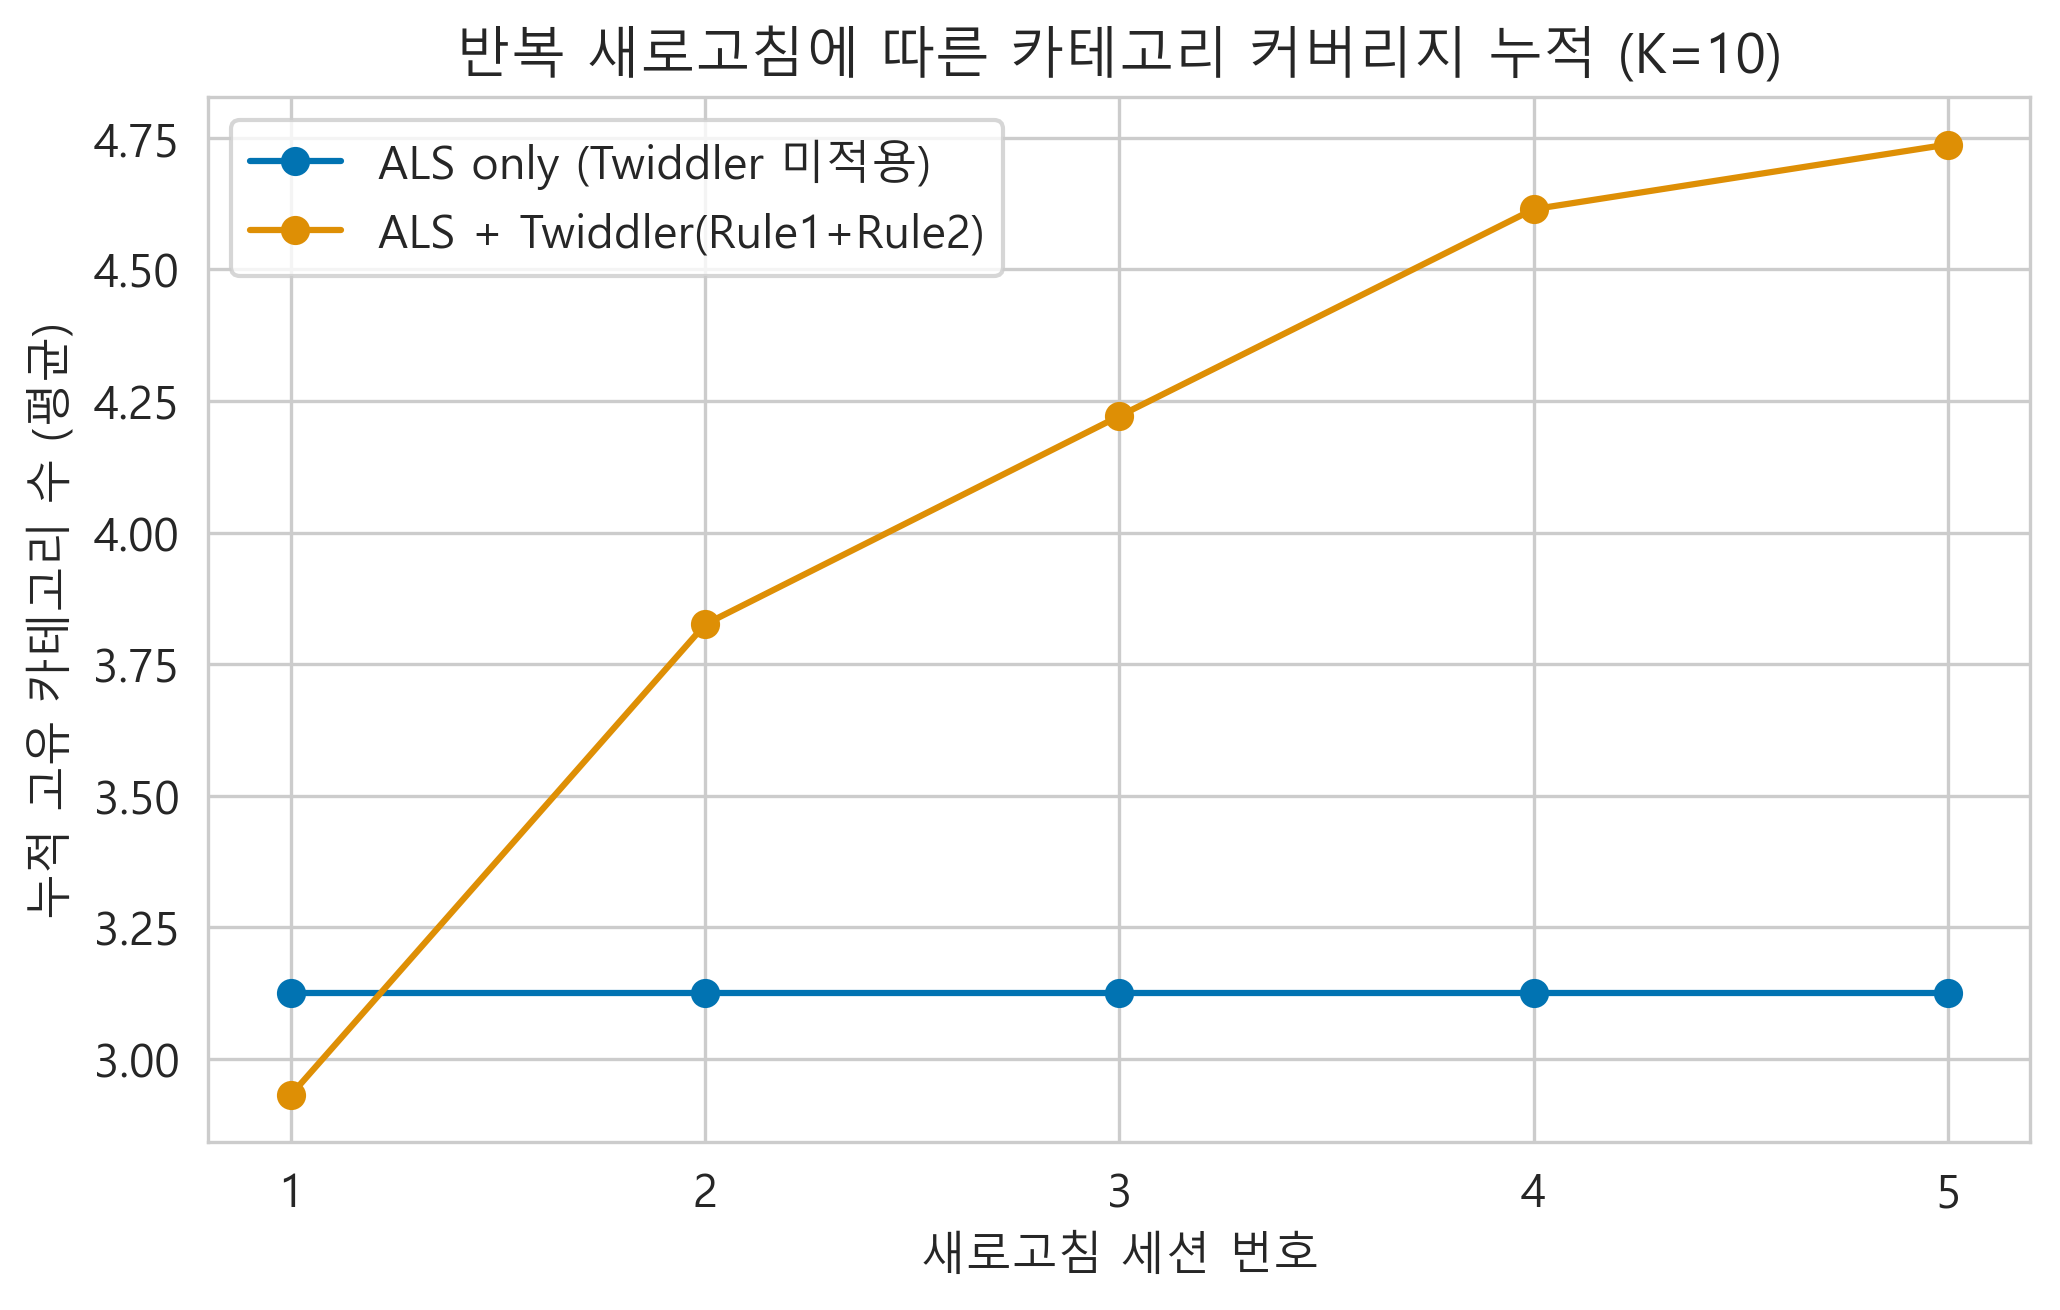

In [9]:
fig2, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(curve_df["session"], curve_df["als_only_categories"], marker="o", label="ALS only (Twiddler 미적용)", color=PALETTE[0])
ax.plot(curve_df["session"], curve_df["rule1_rule2_categories"], marker="o", label="ALS + Twiddler(Rule1+Rule2)", color=PALETTE[1])
ax.set_xlabel("새로고침 세션 번호")
ax.set_ylabel("누적 고유 카테고리 수 (평균)")
ax.set_title("반복 새로고침에 따른 카테고리 커버리지 누적 (K=10)")
ax.legend()
ax.set_xticks(curve_df["session"])
plt.tight_layout()
plt.show()

## 결과 요약

**핵심 발견**
- 1회성 추천만 보면 Rule 1(페르소나 가중치)의 정확도 영향은 K에 따라 엇갈린다(K=5 소폭 개선, K=10 소폭 하락, K=20 거의 중립) — 이전 분석과 동일한 결론.
- Twiddler를 전혀 적용하지 않으면(ALS only, Rule1 only 모두) **새로고침을 5번 반복해도 추천 결과가 100% 동일**하다 — ALS 점수와 Rule 1 배율이 세션에 따라 변하지 않기 때문에 구조적으로 당연한 결과다.
- Rule 2(노출 이력 패널티)까지 포함하면 세션 간 중복률이 K=10 기준 100% → 39.4%로 떨어지고, 고유 아이템 비율은 0.20 → 0.57로, 5세션 누적 카테고리 수는 2.93개 → 4.74개(+61.8%)로 늘어난다.
- 이 효과는 heavy 유저(1,427명)와 cold 유저(36명, 인기도 폴백) 모두에서 비슷한 폭으로 나타난다(중복률 각각 39.5%, 36.8%로 하락) — cold 유저의 정적인 인기도 리스트도 Twiddler를 거치면 새로고침마다 달라진다.

**수치 요약 (K=10, 5회 새로고침 평균)**

| 조건 | 세션 간 중복률 | 고유 아이템 비율 | 카테고리 수(1세션 → 5세션 누적) |
|---|---:|---:|---:|
| ALS only | 100.0% | 0.20 | 3.13 → 3.13 |
| ALS + Rule 1만 | 100.0% | 0.20 | 2.93 → 2.93 |
| ALS + Rule 1 + Rule 2 | 39.4% | 0.57 | 2.93 → 4.74 |

**해석**: Twiddler는 정확도(HR/Recall/NDCG) 개선 장치라기보다 반복 노출 상황에서의 다양성 확보 장치로서의 가치가 뚜렷하다. ALS 원점수 기반 추천은 새로고침해도 아이템이 전혀 바뀌지 않는 구조적 한계가 있으며, Rule 2의 노출 감쇠가 이를 실질적으로 해결한다. 정확도 지표는 K=5 외에는 개선을 뒷받침하지 못하므로, 포스터·발표에서는 "정확도 개선"이 아니라 "반복 방문 시 다양성 확보"를 Twiddler의 핵심 가치로 제시하는 것이 데이터에 부합한다.

**한계**
- T=5(새로고침 횟수)는 임의로 선택한 값이며, 실제 유저의 새로고침 빈도/패턴 데이터로 검증되지 않았다.
- exposure_counts는 유저별로 시뮬레이션 시작 시점에 빈 상태(첫 방문 가정)에서 출발한다. 실제 서비스에서는 이전 방문 이력이 남아있는 경우와 다를 수 있다.
- 카테고리 커버리지의 절대값(전체 7개 카테고리 중 4~5개)은 후보 풀(top pool_n) 자체의 카테고리 분포에 의해 상한이 정해질 수 있어, 후보 풀 크기(POOL_MULTIPLIER)에 따라 값이 달라질 수 있다.
- Rule 3(저노출 상품 보장)은 main 컨텍스트 미적용 규칙이라 이 분석 범위 밖이다 — 상세페이지(detail) 컨텍스트에서는 별도 분석이 필요하다.

**권장 다음 단계**
- 온라인 A/B 지표(체류시간, 재방문율, 클릭 후 이탈률)로 다양성 확보가 실제 사용자 행동에 미치는 영향 확인
- T(새로고침 횟수), `EXPOSURE_DECAY`(현재 0.7) 값에 대한 민감도 분석
- Rule 3까지 포함한 상세페이지(detail) 보완재 추천 컨텍스트에서 동일한 방식의 다양성 분석 수행
